# Further Experiments

In [1]:
import numpy as np
import scipy.io as sio
from pathlib import Path

from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

In [ ]:

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data" / "participants" / "M02"
RESULTS_DIR = PROJECT_ROOT / "results"
EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"

mat_exp2 = DATA_DIR / "data_384sentences.mat"
mat_exp3 = DATA_DIR / "data_243sentences.mat"

embed_dir_exp2 = EMBEDDINGS_DIR / "Qwen_Embedder" / "Experiment2_384"
embed_dir_exp3 = EMBEDDINGS_DIR / "Qwen_Embedder" / "Experiment3_243"

llm_dir_exp2 = EMBEDDINGS_DIR / "Qwen" / "Experiment2_384"
llm_dir_exp3 = EMBEDDINGS_DIR / "Qwen" / "Experiment3_243"

num_layers = 37

ALPHAS = np.logspace(1, 20, 20)

for path in [mat_exp2, mat_exp3, embed_dir_exp2, embed_dir_exp3, llm_dir_exp2, llm_dir_exp3]:
    if not path.exists():
        raise FileNotFoundError(f"Missing path: {path}")

In [ ]:
mat2 = sio.loadmat(mat_exp2)
mat3 = sio.loadmat(mat_exp3)

fmri_exp2_full = mat2["examples_passagesentences"]
fmri_exp3_full = mat3["examples_passagesentences"]

print("Full fMRI exp2:", fmri_exp2_full.shape)
print("Full fMRI exp3:", fmri_exp3_full.shape)


def get_language_roi_columns(mat_path):
    """
    Get the voxel columns corresponding to the left-hemisphere language ROI
    """
    data = sio.loadmat(mat_path, simplify_cells=True)

    target_index = np.where(data["meta"]["atlases"] == "languageLH")[0].item()

    column_indexes = np.concatenate(
        [arr - 1 for arr in data["meta"]["roiColumns"][target_index]],
        axis=0
    )

    return column_indexes


language_columns_exp2 = get_language_roi_columns(mat_exp2)
language_columns_exp3 = get_language_roi_columns(mat_exp3)

fmri_exp2 = fmri_exp2_full[:, language_columns_exp2]
fmri_exp3 = fmri_exp3_full[:, language_columns_exp3]

print("Language ROI fMRI exp2:", fmri_exp2.shape)
print("Language ROI fMRI exp3:", fmri_exp3.shape)

/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Full fMRI exp2: (384, 170712)
Full fMRI exp3: (243, 170712)
Language ROI fMRI exp2: (384, 4930)
Language ROI fMRI exp3: (243, 4930)


In [ ]:
#Topic labels (for residual method) 
topic_labels_exp2 = mat2['labelsPassageCategory']
topic_labels_exp3 = mat3['labelsPassageCategory']

print("Topic labels exp2:", topic_labels_exp2.shape)
print("Sample:", topic_labels_exp2[:5])

# Sentence labels (for reference) 
sentences_exp2 = mat2['labelsSentences']
sentences_exp3 = mat3['labelsSentences']

# labelsPassageForEachSentence maps each sentence --> its passage
passage_per_sentence_exp2 = mat2['labelsPassageForEachSentence']
passage_per_sentence_exp3 = mat3['labelsPassageForEachSentence']

Topic labels exp2: (96, 1)
Sample: [[18]
 [10]
 [12]
 [ 7]
 [23]]


In [ ]:
#  Extract the 24 topic string names
key_cats = mat2['keyPassageCategory'].flatten()
topic_names = np.array([k[0] for k in key_cats])
print("Topic names:", topic_names)

# Map passages --> topic index 
passage_to_topic_idx = mat2['labelsPassageCategory'].flatten() - 1 
print("Passage topic indices:", passage_to_topic_idx[:5]) 

# Map sentences --> passage 
sentence_to_passage = mat2['labelsPassageForEachSentence'].flatten() - 1 
print("Sentence to passage:", sentence_to_passage[:5])

# Combine topic label per sentence 
topic_idx_per_sentence = passage_to_topic_idx[sentence_to_passage]
topic_labels_exp2 = topic_names[topic_idx_per_sentence]

print("Shape:", topic_labels_exp2.shape)   
print("Sample:", topic_labels_exp2[:10])  

key_cats3 = mat3['keyPassageCategory'].flatten()
topic_names3 = np.array([k[0] for k in key_cats3])
passage_to_topic_idx3 = mat3['labelsPassageCategory'].flatten() - 1
sentence_to_passage3 = mat3['labelsPassageForEachSentence'].flatten() - 1
topic_idx_per_sentence3 = passage_to_topic_idx3[sentence_to_passage3]
topic_labels_exp3 = topic_names3[topic_idx_per_sentence3]

print("Exp3 shape:", topic_labels_exp3.shape) 
print("Exp3 sample:", topic_labels_exp3[:10])

Topic names: ['animal' 'appliance' 'bird' 'body_part' 'building_part' 'clothing'
 'crime' 'disaster' 'drink_non_alcoholic' 'dwelling' 'fish' 'fruit'
 'furniture' 'human' 'insect' 'kitchen_utensil' 'landscape' 'music'
 'place' 'profession' 'tool' 'vegetable' 'vehicles_transport' 'weapon']
Passage topic indices: [17  9 11  6 22]
Sentence to passage: [0 0 0 0 1]
Shape: (384,)
Sample: ['music' 'music' 'music' 'music' 'dwelling' 'dwelling' 'dwelling'
 'dwelling' 'fruit' 'fruit']
Exp3 shape: (243,)
Exp3 sample: ['beekeeping' 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping'
 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping' 'beekeeping']


# Random Baseline

In [ ]:
layer_embeddings_llm_exp2 = {}
layer_embeddings_llm_exp3 = {}
layer_embeddings_emb_exp2 = {}
layer_embeddings_emb_exp3 = {}

for layer_idx in range(num_layers):
    layer_embeddings_llm_exp2[layer_idx] = np.load(
    llm_dir_exp2 / f"qwen_layer{layer_idx}.npy"
    )
    layer_embeddings_llm_exp3[layer_idx] = np.load(
        llm_dir_exp3 / f"qwen_layer{layer_idx}.npy"
    )
    layer_embeddings_emb_exp2[layer_idx] = np.load(
        embed_dir_exp2 / f"qwen_layer{layer_idx}.npy"
    )
    layer_embeddings_emb_exp3[layer_idx] = np.load(
        embed_dir_exp3 / f"qwen_layer{layer_idx}.npy"
    )

print("LLM exp2 layer 0:", layer_embeddings_llm_exp2[0].shape)  
print("LLM exp3 layer 0:", layer_embeddings_llm_exp3[0].shape) 
print("Emb exp2 layer 0:", layer_embeddings_emb_exp2[0].shape)  
print("Emb exp3 layer 0:", layer_embeddings_emb_exp3[0].shape)  

LLM exp2 layer 0: (384, 4096)
LLM exp3 layer 0: (243, 4096)
Emb exp2 layer 0: (384, 4096)
Emb exp3 layer 0: (243, 4096)


In [7]:
def voxel_encoding(embeddings, fmri, n_splits=5):
    """Returns mean Pearson r across voxels."""
    kf = KFold(n_splits=n_splits)
    correlations = []

    for train_idx, test_idx in kf.split(embeddings):
        X_train, X_test = embeddings[train_idx], embeddings[test_idx]
        y_train, y_test = fmri[train_idx], fmri[test_idx]

        model = RidgeCV(alphas=ALPHAS)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r_per_voxel = [
            np.corrcoef(y_pred[:, v], y_test[:, v])[0, 1]
            for v in range(fmri.shape[1])
        ]

        correlations.append(np.nanmean(r_per_voxel))

    return np.mean(correlations)

In [8]:
def random_baseline(embeddings, fmri, n_seeds=5):
    scores = []
    for seed in range(n_seeds):
        np.random.seed(seed)
        random_embeddings = np.random.randn(*embeddings.shape)
        scores.append(voxel_encoding(random_embeddings, fmri))
    return np.mean(scores)

In [ ]:
# Voxel-encoding peak layers
enc_peak_llm_exp2 = 10
enc_peak_emb_exp2 = 17
enc_peak_llm_exp3 = 16
enc_peak_emb_exp3 = 25

# Exp2
random_score_exp2_llm = random_baseline(
    layer_embeddings_llm_exp2[enc_peak_llm_exp2], fmri_exp2
)
print(f"Random baseline Exp2 LLM, layer {enc_peak_llm_exp2}: {random_score_exp2_llm:.4f}")

random_score_exp2_emb = random_baseline(
    layer_embeddings_emb_exp2[enc_peak_emb_exp2], fmri_exp2
)
print(f"Random baseline Exp2 Embedder, layer {enc_peak_emb_exp2}: {random_score_exp2_emb:.4f}")

# Exp3
random_score_exp3_llm = random_baseline(
    layer_embeddings_llm_exp3[enc_peak_llm_exp3], fmri_exp3
)
print(f"Random baseline Exp3 LLM, layer {enc_peak_llm_exp3}: {random_score_exp3_llm:.4f}")

random_score_exp3_emb = random_baseline(
    layer_embeddings_emb_exp3[enc_peak_emb_exp3], fmri_exp3
)
print(f"Random baseline Exp3 Embedder, layer {enc_peak_emb_exp3}: {random_score_exp3_emb:.4f}")

/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value e

Random baseline Exp2 LLM, layer 10: -0.0005


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value e

Random baseline Exp2 Embedder, layer 17: -0.0005


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value e

Random baseline Exp3 LLM, layer 16: -0.0172


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value e

Random baseline Exp3 Embedder, layer 25: -0.0172


/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scur0412/NeuroNLP/neuro/lib64/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


RSA

In [10]:
def build_rdm(representations):
    distances = pdist(representations, metric='cosine')
    return squareform(distances)

def compare_rdms(rdm1, rdm2):
    idx = np.triu_indices(rdm1.shape[0], k=1)
    rho, p = spearmanr(rdm1[idx], rdm2[idx])
    return rho, p

def permutation_test(rdm1, rdm2, n_perms=1000):
    observed_rho, _ = compare_rdms(rdm1, rdm2)
    null = []
    for _ in range(n_perms):
        perm = np.random.permutation(rdm1.shape[0])
        rdm1_perm = rdm1[np.ix_(perm, perm)]
        null.append(compare_rdms(rdm1_perm, rdm2)[0])
    p_value = np.mean(np.array(null) >= observed_rho)
    return observed_rho, p_value

brain_rdm_exp2 = build_rdm(fmri_exp2)  
brain_rdm_exp3 = build_rdm(fmri_exp3)  
print("Brain RDM exp2:", brain_rdm_exp2.shape)
print("Brain RDM exp3:", brain_rdm_exp3.shape)

def build_topic_rdm(topic_labels):
    n = len(topic_labels)
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            rdm[i, j] = 0 if topic_labels[i] == topic_labels[j] else 1
    return rdm

topic_rdm_exp2 = build_topic_rdm(topic_labels_exp2)
topic_rdm_exp3 = build_topic_rdm(topic_labels_exp3)

topic_brain_rho_exp2, _ = compare_rdms(topic_rdm_exp2, brain_rdm_exp2)
topic_brain_rho_exp3, _ = compare_rdms(topic_rdm_exp3, brain_rdm_exp3)
print(f"Topic→Brain RSA exp2: {topic_brain_rho_exp2:.4f}")
print(f"Topic→Brain RSA exp3: {topic_brain_rho_exp3:.4f}")

Brain RDM exp2: (384, 384)
Brain RDM exp3: (243, 243)
Topic→Brain RSA exp2: 0.0385
Topic→Brain RSA exp3: 0.0468


In [11]:
rsa_llm_exp2, rsa_emb_exp2 = {}, {}
rsa_llm_exp3, rsa_emb_exp3 = {}, {}

for layer in range(1, num_layers):
    print(f"Layer {layer}...", end="\r")

    rsa_llm_exp2[layer] = compare_rdms(
        build_rdm(layer_embeddings_llm_exp2[layer]), brain_rdm_exp2
    )
    rsa_emb_exp2[layer] = compare_rdms(
        build_rdm(layer_embeddings_emb_exp2[layer]), brain_rdm_exp2
    )
    rsa_llm_exp3[layer] = compare_rdms(
        build_rdm(layer_embeddings_llm_exp3[layer]), brain_rdm_exp3
    )
    rsa_emb_exp3[layer] = compare_rdms(
        build_rdm(layer_embeddings_emb_exp3[layer]), brain_rdm_exp3
    )

print("RSA complete")

rsa_peak_llm_exp2 = max(rsa_llm_exp2, key=lambda l: rsa_llm_exp2[l][0])
rsa_peak_emb_exp2 = max(rsa_emb_exp2, key=lambda l: rsa_emb_exp2[l][0])
rsa_peak_llm_exp3 = max(rsa_llm_exp3, key=lambda l: rsa_llm_exp3[l][0])
rsa_peak_emb_exp3 = max(rsa_emb_exp3, key=lambda l: rsa_emb_exp3[l][0])

print(f"\nExp2 — LLM RSA peak: layer {rsa_peak_llm_exp2}, rho={rsa_llm_exp2[rsa_peak_llm_exp2][0]:.4f}")
print(f"Exp2 — Embedder RSA peak: layer {rsa_peak_emb_exp2}, rho={rsa_emb_exp2[rsa_peak_emb_exp2][0]:.4f}")
print(f"Exp3 — LLM RSA peak: layer {rsa_peak_llm_exp3}, rho={rsa_llm_exp3[rsa_peak_llm_exp3][0]:.4f}")
print(f"Exp3 — Embedder RSA peak: layer {rsa_peak_emb_exp3}, rho={rsa_emb_exp3[rsa_peak_emb_exp3][0]:.4f}")

RSA complete

Exp2 — LLM RSA peak: layer 2, rho=0.0464
Exp2 — Embedder RSA peak: layer 27, rho=0.1023
Exp3 — LLM RSA peak: layer 9, rho=0.1216
Exp3 — Embedder RSA peak: layer 31, rho=0.1055


In [ ]:
def compute_residual_embeddings(embeddings, topic_labels):
    """
    Reduce topic-predictive directions in the embedding space.
    Returns residual embeddings with reduced broad-topic information.
    """
    le = LabelEncoder()
    y = le.fit_transform(topic_labels)

    # Train linear classifier to find topic subspace
    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(embeddings, y)
    topic_subspace = clf.coef_  

    # Orthogonal projection to remove topic directions
    W = topic_subspace  
    WWT_inv = np.linalg.pinv(W @ W.T)
    projection = (W.T @ WWT_inv @ W @ embeddings.T).T

    residuals = embeddings - projection
    return residuals

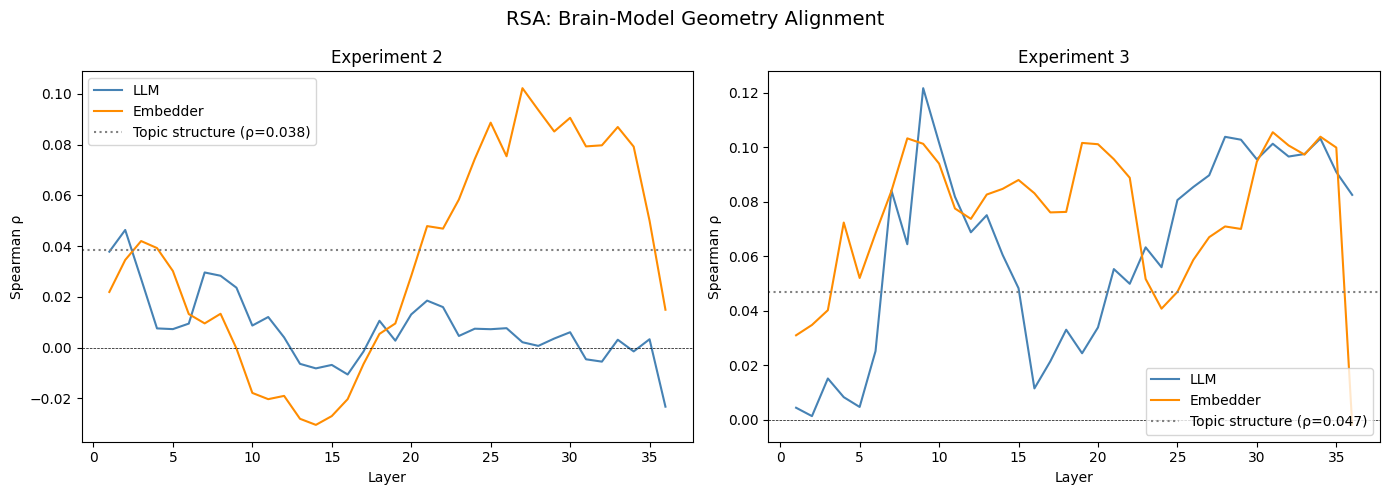

In [13]:
import matplotlib.pyplot as plt

layers = list(range(1, num_layers)) 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RSA: Brain-Model Geometry Alignment', fontsize=14)

# Experiment 2 
ax = axes[0]
ax.plot(layers, [rsa_llm_exp2[l][0] for l in layers], label='LLM', color='steelblue')
ax.plot(layers, [rsa_emb_exp2[l][0] for l in layers], label='Embedder', color='darkorange')
ax.axhline(topic_brain_rho_exp2, color='gray', linestyle=':', label=f'Topic structure (ρ={topic_brain_rho_exp2:.3f})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Experiment 2')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
ax.legend()

# Experiment 3 
ax = axes[1]
ax.plot(layers, [rsa_llm_exp3[l][0] for l in layers], label='LLM', color='steelblue')
ax.plot(layers, [rsa_emb_exp3[l][0] for l in layers], label='Embedder', color='darkorange')
ax.axhline(topic_brain_rho_exp3, color='gray', linestyle=':', label=f'Topic structure (ρ={topic_brain_rho_exp3:.3f})')
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Experiment 3')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
ax.legend()

plt.tight_layout()
plt.savefig('rsa_results.png', dpi=150)
plt.show()

Residual Method

In [ ]:
enc_peak_llm_exp2 = 10
enc_peak_emb_exp2 = 17
enc_peak_llm_exp3 = 16
enc_peak_emb_exp3 = 25

# residual embeddings at voxel-encoding peak layers
res_llm_exp2 = compute_residual_embeddings(
    layer_embeddings_llm_exp2[enc_peak_llm_exp2], topic_labels_exp2
)
res_emb_exp2 = compute_residual_embeddings(
    layer_embeddings_emb_exp2[enc_peak_emb_exp2], topic_labels_exp2
)
res_llm_exp3 = compute_residual_embeddings(
    layer_embeddings_llm_exp3[enc_peak_llm_exp3], topic_labels_exp3
)
res_emb_exp3 = compute_residual_embeddings(
    layer_embeddings_emb_exp3[enc_peak_emb_exp3], topic_labels_exp3
)

print("Residual embeddings computed")
print("LLM exp2 residual shape:", res_llm_exp2.shape)
print("Emb exp2 residual shape:", res_emb_exp2.shape)
print("LLM exp3 residual shape:", res_llm_exp3.shape)
print("Emb exp3 residual shape:", res_emb_exp3.shape)

Residual embeddings computed
LLM exp2 residual shape: (384, 4096)
Emb exp2 residual shape: (384, 4096)
LLM exp3 residual shape: (243, 4096)
Emb exp3 residual shape: (243, 4096)


In [ ]:
print("Running residual voxel encoding... (this may take 10-20 mins)")

print("Computing baselines...")

base_llm_exp2 = voxel_encoding(
    layer_embeddings_llm_exp2[enc_peak_llm_exp2], fmri_exp2
)
base_emb_exp2 = voxel_encoding(
    layer_embeddings_emb_exp2[enc_peak_emb_exp2], fmri_exp2
)
base_llm_exp3 = voxel_encoding(
    layer_embeddings_llm_exp3[enc_peak_llm_exp3], fmri_exp3
)
base_emb_exp3 = voxel_encoding(
    layer_embeddings_emb_exp3[enc_peak_emb_exp3], fmri_exp3
)

print("Computing residuals...")

resid_llm_exp2 = voxel_encoding(res_llm_exp2, fmri_exp2)
resid_emb_exp2 = voxel_encoding(res_emb_exp2, fmri_exp2)
resid_llm_exp3 = voxel_encoding(res_llm_exp3, fmri_exp3)
resid_emb_exp3 = voxel_encoding(res_emb_exp3, fmri_exp3)

print("\n=== Residual-method results ===")
print(
    f"Exp2 LLM, layer {enc_peak_llm_exp2} — "
    f"baseline: {base_llm_exp2:.4f} | "
    f"residual: {resid_llm_exp2:.4f} | "
    f"drop: {base_llm_exp2 - resid_llm_exp2:.4f} | "
    f"drop %: {100 * (base_llm_exp2 - resid_llm_exp2) / base_llm_exp2:.1f}%"
)
print(
    f"Exp2 Embedder, layer {enc_peak_emb_exp2} — "
    f"baseline: {base_emb_exp2:.4f} | "
    f"residual: {resid_emb_exp2:.4f} | "
    f"drop: {base_emb_exp2 - resid_emb_exp2:.4f} | "
    f"drop %: {100 * (base_emb_exp2 - resid_emb_exp2) / base_emb_exp2:.1f}%"
)
print(
    f"Exp3 LLM, layer {enc_peak_llm_exp3} — "
    f"baseline: {base_llm_exp3:.4f} | "
    f"residual: {resid_llm_exp3:.4f} | "
    f"drop: {base_llm_exp3 - resid_llm_exp3:.4f} | "
    f"drop %: {100 * (base_llm_exp3 - resid_llm_exp3) / base_llm_exp3:.1f}%"
)
print(
    f"Exp3 Embedder, layer {enc_peak_emb_exp3} — "
    f"baseline: {base_emb_exp3:.4f} | "
    f"residual: {resid_emb_exp3:.4f} | "
    f"drop: {base_emb_exp3 - resid_emb_exp3:.4f} | "
    f"drop %: {100 * (base_emb_exp3 - resid_emb_exp3) / base_emb_exp3:.1f}%"
)

Running residual voxel encoding... (this may take 10-20 mins)
Computing baselines...
Computing residuals...

=== Residual-method results ===
Exp2 LLM, layer 10 — baseline: 0.2298 | residual: 0.1545 | drop: 0.0754 | drop %: 32.8%
Exp2 Embedder, layer 17 — baseline: 0.2544 | residual: 0.2180 | drop: 0.0363 | drop %: 14.3%
Exp3 LLM, layer 16 — baseline: 0.2460 | residual: 0.2451 | drop: 0.0010 | drop %: 0.4%
Exp3 Embedder, layer 25 — baseline: 0.2630 | residual: 0.2154 | drop: 0.0476 | drop %: 18.1%


In [16]:
import matplotlib.pyplot as plt

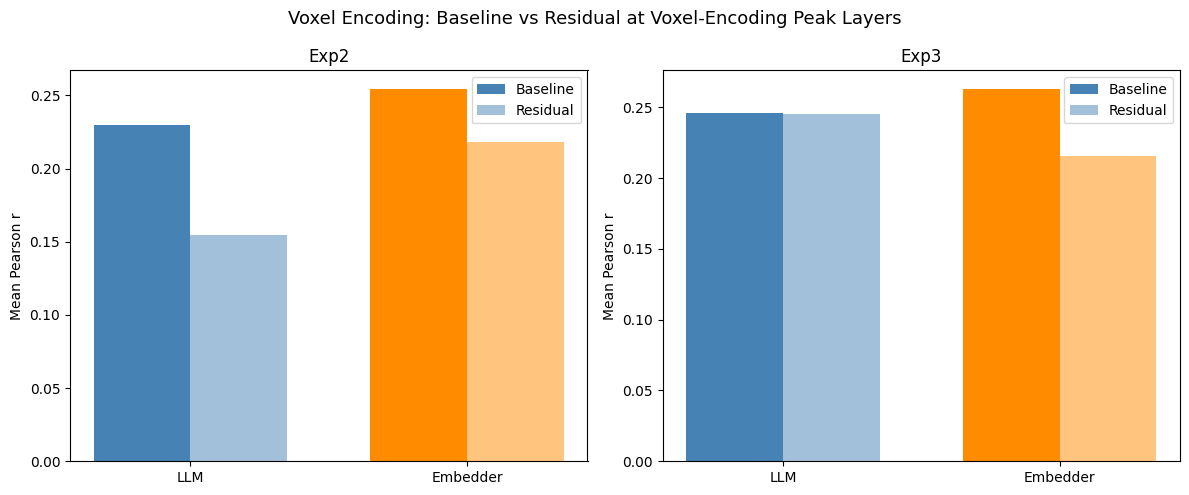

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Voxel Encoding: Baseline vs Residual at Voxel-Encoding Peak Layers', fontsize=13)

for ax, exp, models in zip(axes, ['Exp2', 'Exp3'], [
    [('LLM', base_llm_exp2, resid_llm_exp2),
     ('Embedder', base_emb_exp2, resid_emb_exp2)],
    [('LLM', base_llm_exp3, resid_llm_exp3),
     ('Embedder', base_emb_exp3, resid_emb_exp3)]
]):
    x = np.arange(len(models))
    width = 0.35
    bars1 = ax.bar(x - width/2, [m[1] for m in models], width, 
                   label='Baseline', color=['steelblue', 'darkorange'])
    bars2 = ax.bar(x + width/2, [m[2] for m in models], width,
                   label='Residual', color=['steelblue', 'darkorange'], alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m[0] for m in models])
    ax.set_ylabel('Mean Pearson r')
    ax.set_title(f'{exp}')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('residual_results.png', dpi=150)
plt.show()